In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. On charge les données qu'on a sauvegardées à la fin du EDA
df_students = pd.read_csv('../data/processed/students_features.csv')

# 2. On crée notre "Cible" (Target) : Ce qu'on veut prédire
# On définit qu'un étudiant est "à risque" (1) si sa moyenne est < 10 OU s'il a plus de 5 absences.
# Sinon, il va bien (0).
df_students['est_a_risque'] = ((df_students['moyenne_generale'] < 10) | (df_students['nb_absences'] > 5)).astype(int)

print(f"✅ Données chargées : {len(df_students)} étudiants.")
print(f"📊 Répartition : {df_students['est_a_risque'].value_counts().to_dict()}")
print("   (1 = À risque, 0 = Va bien)")

display(df_students.head())

✅ Données chargées : 147 étudiants.
📊 Répartition : {0: 128, 1: 19}
   (1 = À risque, 0 = Va bien)


,id_etudiant,moyenne_generale,nb_absences,id,nom,prenom,nom_complet,score_risque,segmentation,est_a_risque
0,1,13.500000,4,1,Rodriguez,Léna,Rodriguez Léna,8.0,Excellent,0
1,3,12.000000,2,3,Paul,Jacques,Paul Jacques,4.0,Excellent,0
2,4,10.000000,2,4,Carpentier,Joël,Carpentier Joël,4.0,Excellent,0
3,5,10.666667,1,5,Leclercq,Anne,Leclercq Anne,2.0,Excellent,0
4,6,13.000000,5,6,Roche,Albéric,Roche Albéric,10.0,Excellent,0


🤖 PERFORMANCE DU MODÈLE PRÉDICTIF (Bonus A)
✅ Accuracy  (Précision globale) : 1.00
🎯 Precision (Fiabilité des alertes) : 1.00
🔍 Recall    (Capacité à trouver les à risque) : 1.00
⚖️ F1-Score  (Moyenne harmonieuse) : 1.00


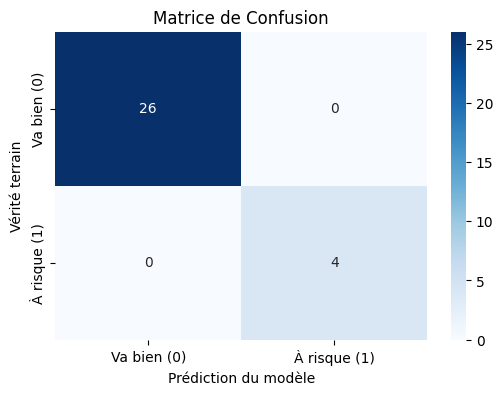


📋 RAPPORT DÉTAILLÉ :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00         4

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

# 1. Préparation des données pour l'IA
# On prend la moyenne et les absences comme "features" (caractéristiques)
X = df_students[['moyenne_generale', 'nb_absences']]
y = df_students['est_a_risque']  # Ce qu'on veut prédire

# 2. Séparation : 80% pour entraîner, 20% pour tester
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# ⚠️ stratify=y permet de garder la même proportion de 0 et 1 dans les deux groupes

# 3. Création du modèle Random Forest (Bonus A)
# ⭐ class_weight='balanced' est L'ASTUCE MAGIQUE pour ton déséquilibre !
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# 4. Entraînement
model.fit(X_train, y_train)

# 5. Prédictions
y_pred = model.predict(X_test)

# 6. Affichage des métriques (Exigence du Bonus A)
print("🤖 PERFORMANCE DU MODÈLE PRÉDICTIF (Bonus A)")
print("=" * 50)
print(f"✅ Accuracy  (Précision globale) : {accuracy_score(y_test, y_pred):.2f}")
print(f"🎯 Precision (Fiabilité des alertes) : {precision_score(y_test, y_pred, zero_division=0):.2f}")
print(f"🔍 Recall    (Capacité à trouver les à risque) : {recall_score(y_test, y_pred, zero_division=0):.2f}")
print(f"⚖️ F1-Score  (Moyenne harmonieuse) : {f1_score(y_test, y_pred, zero_division=0):.2f}")

# 7. Matrice de confusion (Graphique)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Va bien (0)', 'À risque (1)'], 
            yticklabels=['Va bien (0)', 'À risque (1)'])
plt.title("Matrice de Confusion")
plt.ylabel("Vérité terrain")
plt.xlabel("Prédiction du modèle")
plt.show()

# 8. Rapport complet
print("\n📋 RAPPORT DÉTAILLÉ :")
print(classification_report(y_test, y_pred, zero_division=1))